In [167]:
import pandas as pd
import numpy as np
from utils.knn import KNN
from utils.metrics_evaluator import MetricsEvaluator
from utils.k_fold_cross_validation import KFoldCrossValidation
from utils.helpers import min_max_normalization, to_percent

In [ ]:
# dm2 anu murni dm2 hngkl
# dm2-all anu boga panyakit lain diasupken, tuluy direname
df = pd.read_csv("dataset-dm2.csv")
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa
0,43.0,L,90.0,70.0,154.0,DM2
1,77.0,P,160.0,90.0,71.0,DM2
2,38.0,P,90.0,70.0,154.0,DM2
3,41.0,P,NaN,NaN,NaN,DM2
4,42.0,P,NaN,NaN,227.0,DM2
...,...,...,...,...,...,...
801,35.0,Perempuan,127.0,84.0,118.0,NDM
802,23.0,Perempuan,121.0,79.0,109.0,NDM
803,29.0,Perempuan,118.0,74.0,96.0,NDM
804,22.0,Perempuan,119.0,78.0,95.0,NDM


In [59]:
missingSistolikCount = df['sistolik'].isna().sum()
print(missingSistolikCount)

24


In [60]:
# Filling missing 'sistolik' values with the mean
df['sistolik'] = df['sistolik'].fillna(df['sistolik'].mean())
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa
0,43.0,L,90.000000,70.0,154.0,DM2
1,77.0,P,160.000000,90.0,71.0,DM2
2,38.0,P,90.000000,70.0,154.0,DM2
3,41.0,P,126.200767,NaN,NaN,DM2
4,42.0,P,126.200767,NaN,227.0,DM2
...,...,...,...,...,...,...
801,35.0,Perempuan,127.000000,84.0,118.0,NDM
802,23.0,Perempuan,121.000000,79.0,109.0,NDM
803,29.0,Perempuan,118.000000,74.0,96.0,NDM
804,22.0,Perempuan,119.000000,78.0,95.0,NDM


In [62]:
missingDiastolikCount = df['diastolik'].isna().sum()
print(missingDiastolikCount)

24


In [63]:
# Mengisi nilai yang hilang pada kolom Diastolik dengan nilai rata-rata mean (nilai rata-rata)
df['diastolik'] = df['diastolik'].fillna(df['diastolik'].mean())
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa
0,43.0,L,90.000000,70.000000,154.0,DM2
1,77.0,P,160.000000,90.000000,71.0,DM2
2,38.0,P,90.000000,70.000000,154.0,DM2
3,41.0,P,126.200767,80.202046,NaN,DM2
4,42.0,P,126.200767,80.202046,227.0,DM2
...,...,...,...,...,...,...
801,35.0,Perempuan,127.000000,84.000000,118.0,NDM
802,23.0,Perempuan,121.000000,79.000000,109.0,NDM
803,29.0,Perempuan,118.000000,74.000000,96.0,NDM
804,22.0,Perempuan,119.000000,78.000000,95.0,NDM


In [64]:
missingGdsCount = df['gds'].isna().sum()
print(missingGdsCount)

36


In [65]:
# Mengisi nilai yang hilang pada kolom gds dengan nilai median (nilai tengah)
df['gds'] = df['gds'].fillna(df['gds'].median())
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa
0,43.0,L,90.000000,70.000000,154.0,DM2
1,77.0,P,160.000000,90.000000,71.0,DM2
2,38.0,P,90.000000,70.000000,154.0,DM2
3,41.0,P,126.200767,80.202046,154.0,DM2
4,42.0,P,126.200767,80.202046,227.0,DM2
...,...,...,...,...,...,...
801,35.0,Perempuan,127.000000,84.000000,118.0,NDM
802,23.0,Perempuan,121.000000,79.000000,109.0,NDM
803,29.0,Perempuan,118.000000,74.000000,96.0,NDM
804,22.0,Perempuan,119.000000,78.000000,95.0,NDM


In [66]:
missingGenderCount = df['jenis_kelamin'].isna().sum()
print(missingGenderCount)

0


In [67]:
# Mengisi nilai yang hilang pada kolom jenis_kelamin dengan nilai modus (nilai yang sering mucul)
df['jenis_kelamin'] = df['jenis_kelamin'].fillna(df['jenis_kelamin'].mode()[0])
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa
0,43.0,L,90.000000,70.000000,154.0,DM2
1,77.0,P,160.000000,90.000000,71.0,DM2
2,38.0,P,90.000000,70.000000,154.0,DM2
3,41.0,P,126.200767,80.202046,154.0,DM2
4,42.0,P,126.200767,80.202046,227.0,DM2
...,...,...,...,...,...,...
801,35.0,Perempuan,127.000000,84.000000,118.0,NDM
802,23.0,Perempuan,121.000000,79.000000,109.0,NDM
803,29.0,Perempuan,118.000000,74.000000,96.0,NDM
804,22.0,Perempuan,119.000000,78.000000,95.0,NDM


In [68]:
# Mapping Gender: P (Perempuan) to 1, L (Laki-laki) to 0
df['transformed_gender'] = df['jenis_kelamin'].map(lambda e: 1 if e == 'P' or e == 'Perempuan' else 0)
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa,transformed_gender
0,43.0,L,90.000000,70.000000,154.0,DM2,0
1,77.0,P,160.000000,90.000000,71.0,DM2,1
2,38.0,P,90.000000,70.000000,154.0,DM2,1
3,41.0,P,126.200767,80.202046,154.0,DM2,1
4,42.0,P,126.200767,80.202046,227.0,DM2,1
...,...,...,...,...,...,...,...
801,35.0,Perempuan,127.000000,84.000000,118.0,NDM,1
802,23.0,Perempuan,121.000000,79.000000,109.0,NDM,1
803,29.0,Perempuan,118.000000,74.000000,96.0,NDM,1
804,22.0,Perempuan,119.000000,78.000000,95.0,NDM,1


In [69]:
df['diagnosa'] = df['diagnosa'].map(lambda e: 1 if e == 'DM2' else 0)
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa,transformed_gender
0,43.0,L,90.000000,70.000000,154.0,1,0
1,77.0,P,160.000000,90.000000,71.0,1,1
2,38.0,P,90.000000,70.000000,154.0,1,1
3,41.0,P,126.200767,80.202046,154.0,1,1
4,42.0,P,126.200767,80.202046,227.0,1,1
...,...,...,...,...,...,...,...
801,35.0,Perempuan,127.000000,84.000000,118.0,0,1
802,23.0,Perempuan,121.000000,79.000000,109.0,0,1
803,29.0,Perempuan,118.000000,74.000000,96.0,0,1
804,22.0,Perempuan,119.000000,78.000000,95.0,0,1


In [70]:
# Normalisasi kolom sistolik
df['norm_sistolik'] = min_max_normalization(df['sistolik'])
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa,transformed_gender,norm_sistolik
0,43.0,L,90.000000,70.000000,154.0,1,0,0.090909
1,77.0,P,160.000000,90.000000,71.0,1,1,0.727273
2,38.0,P,90.000000,70.000000,154.0,1,1,0.090909
3,41.0,P,126.200767,80.202046,154.0,1,1,0.420007
4,42.0,P,126.200767,80.202046,227.0,1,1,0.420007
...,...,...,...,...,...,...,...,...
801,35.0,Perempuan,127.000000,84.000000,118.0,0,1,0.427273
802,23.0,Perempuan,121.000000,79.000000,109.0,0,1,0.372727
803,29.0,Perempuan,118.000000,74.000000,96.0,0,1,0.345455
804,22.0,Perempuan,119.000000,78.000000,95.0,0,1,0.354545


In [71]:
# Normalisasi kolom diastolik
df['norm_diastolik'] = min_max_normalization(df['diastolik'])
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa,transformed_gender,norm_sistolik,norm_diastolik
0,43.0,L,90.000000,70.000000,154.0,1,0,0.090909,0.19000
1,77.0,P,160.000000,90.000000,71.0,1,1,0.727273,0.39000
2,38.0,P,90.000000,70.000000,154.0,1,1,0.090909,0.19000
3,41.0,P,126.200767,80.202046,154.0,1,1,0.420007,0.29202
4,42.0,P,126.200767,80.202046,227.0,1,1,0.420007,0.29202
...,...,...,...,...,...,...,...,...,...
801,35.0,Perempuan,127.000000,84.000000,118.0,0,1,0.427273,0.33000
802,23.0,Perempuan,121.000000,79.000000,109.0,0,1,0.372727,0.28000
803,29.0,Perempuan,118.000000,74.000000,96.0,0,1,0.345455,0.23000
804,22.0,Perempuan,119.000000,78.000000,95.0,0,1,0.354545,0.27000


In [72]:
# Normalisasi kolom Umur
df['norm_umur'] = min_max_normalization(df['umur'])
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa,transformed_gender,norm_sistolik,norm_diastolik,norm_umur
0,43.0,L,90.000000,70.000000,154.0,1,0,0.090909,0.19000,0.065250
1,77.0,P,160.000000,90.000000,71.0,1,1,0.727273,0.39000,0.116844
2,38.0,P,90.000000,70.000000,154.0,1,1,0.090909,0.19000,0.057663
3,41.0,P,126.200767,80.202046,154.0,1,1,0.420007,0.29202,0.062215
4,42.0,P,126.200767,80.202046,227.0,1,1,0.420007,0.29202,0.063733
...,...,...,...,...,...,...,...,...,...,...
801,35.0,Perempuan,127.000000,84.000000,118.0,0,1,0.427273,0.33000,0.053111
802,23.0,Perempuan,121.000000,79.000000,109.0,0,1,0.372727,0.28000,0.034901
803,29.0,Perempuan,118.000000,74.000000,96.0,0,1,0.345455,0.23000,0.044006
804,22.0,Perempuan,119.000000,78.000000,95.0,0,1,0.354545,0.27000,0.033384


In [73]:
# Normalisasi kolom gds (Gula Darah Sewaktu)
df['norm_gds'] = min_max_normalization(df['gds'])
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa,transformed_gender,norm_sistolik,norm_diastolik,norm_umur,norm_gds
0,43.0,L,90.000000,70.000000,154.0,1,0,0.090909,0.19000,0.065250,0.157076
1,77.0,P,160.000000,90.000000,71.0,1,1,0.727273,0.39000,0.116844,0.027994
2,38.0,P,90.000000,70.000000,154.0,1,1,0.090909,0.19000,0.057663,0.157076
3,41.0,P,126.200767,80.202046,154.0,1,1,0.420007,0.29202,0.062215,0.157076
4,42.0,P,126.200767,80.202046,227.0,1,1,0.420007,0.29202,0.063733,0.270607
...,...,...,...,...,...,...,...,...,...,...,...
801,35.0,Perempuan,127.000000,84.000000,118.0,0,1,0.427273,0.33000,0.053111,0.101089
802,23.0,Perempuan,121.000000,79.000000,109.0,0,1,0.372727,0.28000,0.034901,0.087092
803,29.0,Perempuan,118.000000,74.000000,96.0,0,1,0.345455,0.23000,0.044006,0.066874
804,22.0,Perempuan,119.000000,78.000000,95.0,0,1,0.354545,0.27000,0.033384,0.065319


In [74]:
newDf = df[['umur', 'sistolik', 'diastolik', 'gds', 'transformed_gender', 'norm_sistolik', 'norm_diastolik', 'norm_umur', 'norm_gds', 'diagnosa']]
newDf

,umur,sistolik,diastolik,gds,transformed_gender,norm_sistolik,norm_diastolik,norm_umur,norm_gds,diagnosa
0,43.0,90.000000,70.000000,154.0,0,0.090909,0.19000,0.065250,0.157076,1
1,77.0,160.000000,90.000000,71.0,1,0.727273,0.39000,0.116844,0.027994,1
2,38.0,90.000000,70.000000,154.0,1,0.090909,0.19000,0.057663,0.157076,1
3,41.0,126.200767,80.202046,154.0,1,0.420007,0.29202,0.062215,0.157076,1
4,42.0,126.200767,80.202046,227.0,1,0.420007,0.29202,0.063733,0.270607,1
...,...,...,...,...,...,...,...,...,...,...
801,35.0,127.000000,84.000000,118.0,1,0.427273,0.33000,0.053111,0.101089,0
802,23.0,121.000000,79.000000,109.0,1,0.372727,0.28000,0.034901,0.087092,0
803,29.0,118.000000,74.000000,96.0,1,0.345455,0.23000,0.044006,0.066874,0
804,22.0,119.000000,78.000000,95.0,1,0.354545,0.27000,0.033384,0.065319,0


In [75]:
reorderDf = newDf.sample(frac=1).reset_index(drop=True)
reorderDf

,umur,sistolik,diastolik,gds,transformed_gender,norm_sistolik,norm_diastolik,norm_umur,norm_gds,diagnosa
0,17.0,115.0,74.0,115.0,1,0.318182,0.23,0.025797,0.096423,0
1,68.0,123.0,89.0,140.0,1,0.390909,0.38,0.103187,0.135303,1
2,58.0,129.0,78.0,84.0,1,0.445455,0.27,0.088012,0.048212,0
3,61.0,130.0,78.0,247.0,1,0.454545,0.27,0.092564,0.301711,0
4,30.0,127.0,75.0,126.0,1,0.427273,0.24,0.045524,0.113530,0
...,...,...,...,...,...,...,...,...,...,...
801,26.0,116.0,82.0,152.0,0,0.327273,0.31,0.039454,0.153966,0
802,50.0,139.0,90.0,224.0,1,0.536364,0.39,0.075873,0.265941,1
803,50.0,146.0,90.0,342.0,1,0.600000,0.39,0.075873,0.449456,1
804,32.0,128.0,74.0,107.0,1,0.436364,0.23,0.048558,0.083981,0


In [20]:
reorderDf.to_csv("dataset_preprocessed.csv", index=False)

# Pembagian Data
Membagi dataset menjadi data latih (80%) dan data uji (20%).

In [76]:
# Menghitung jumlah data untuk training (80% dari total dataset)
training_count = int(df.shape[0] * 0.8)
print(f"Jumlah data training: {training_count}")

Jumlah data training: 644


In [77]:
# Memisahkan fitur (X) dan target (y)
X = reorderDf[['norm_sistolik', 'norm_diastolik', 'norm_umur', 'norm_gds', 'transformed_gender']]
y = reorderDf['diagnosa']

# Membagi dataset menjadi data Latih (Train) dan data Uji (Test)
X_train = X.iloc[:training_count]
y_train = y.iloc[:training_count]
X_test = X.iloc[training_count:]
y_test = y.iloc[training_count:]

print("Dimensi data latih - {},{}".format(X_train.shape, y_train.shape))
print("Dimensi data validasi - {},{}".format(X_test.shape, y_test.shape))

Dimensi data latih - (644, 5),(644,)
Dimensi data validasi - (162, 5),(162,)


Results for Euclidean Distance (K=3)
Accuracy: 82.10%, Precision: 85.71%, Recall: 80.90%, F1-Score: 83.24%
--------------------------------------------------------------------------------
Results for Manhattan Distance (K=3)
Accuracy: 84.57%, Precision: 88.10%, Recall: 83.15%, F1-Score: 85.55%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=5)
Accuracy: 80.25%, Precision: 85.19%, Recall: 77.53%, F1-Score: 81.18%
--------------------------------------------------------------------------------
Results for Manhattan Distance (K=5)
Accuracy: 82.72%, Precision: 86.75%, Recall: 80.90%, F1-Score: 83.72%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=7)
Accuracy: 80.86%, Precision: 85.37%, Recall: 78.65%, F1-Score: 81.87%
--------------------------------------------------------------------------------
Results for Manhattan Distance (K=7)
Accuracy: 81.48%, Preci

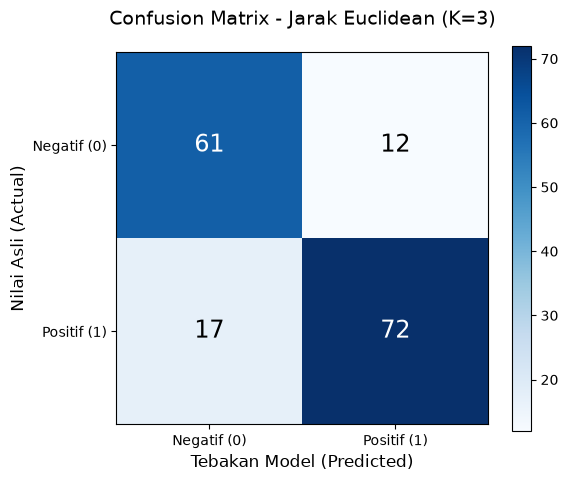

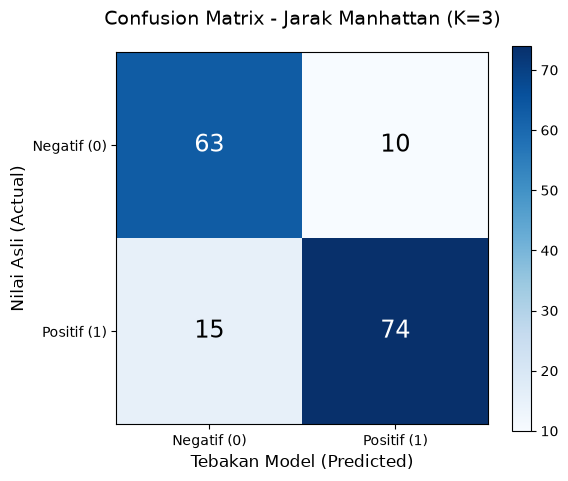

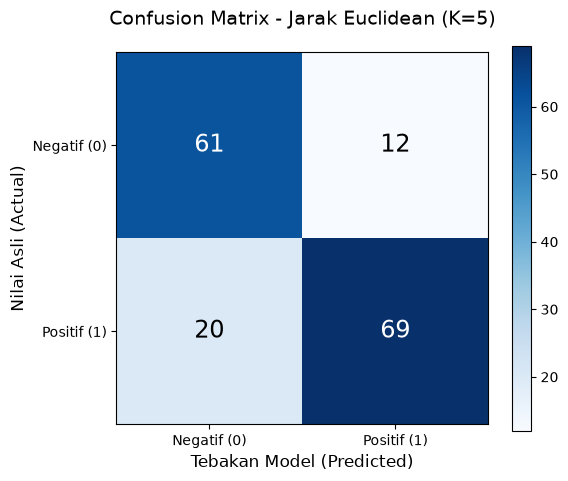

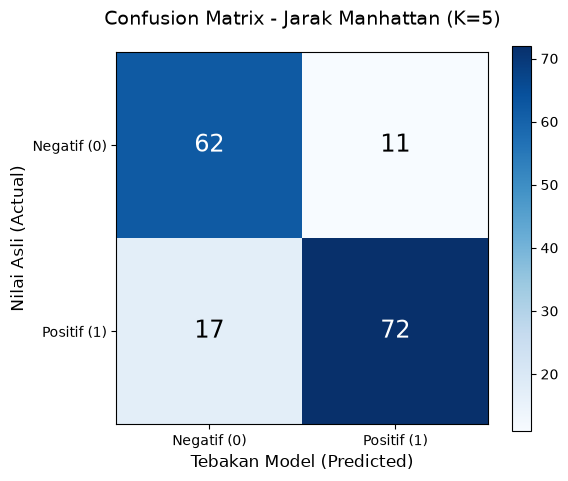

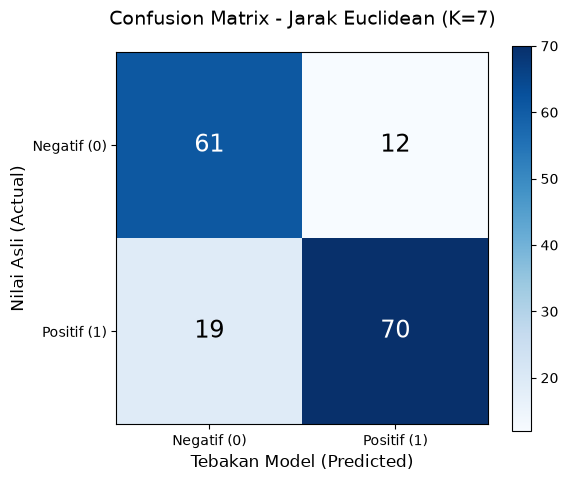

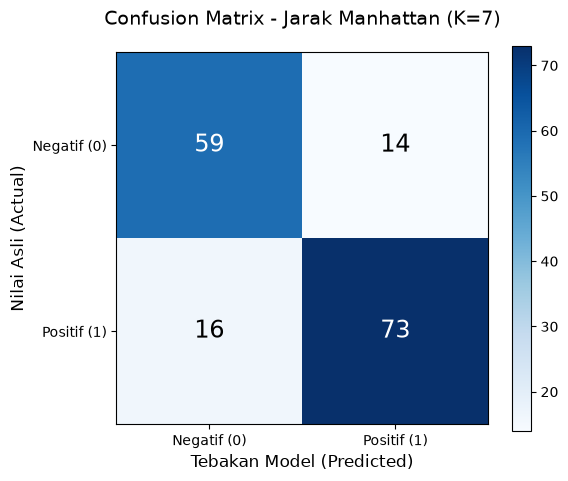

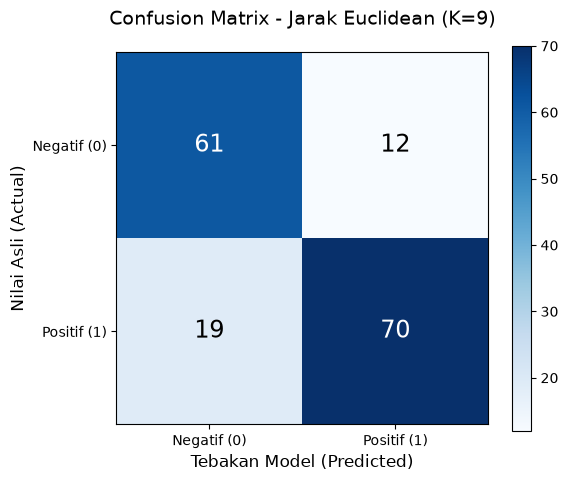

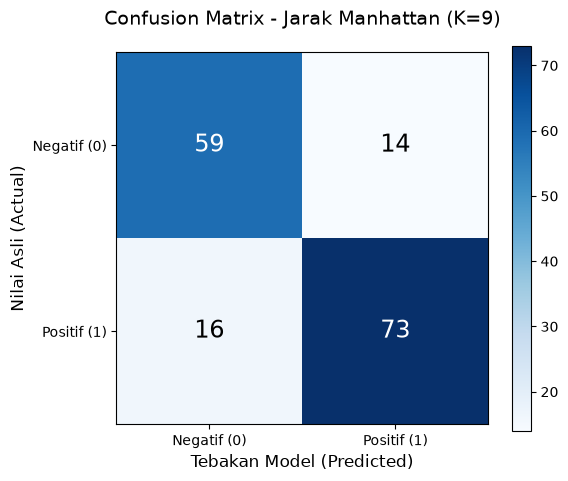

In [78]:
# Iterate through different K values and distance metrics to evaluate performance
for k_count in np.array([3, 5, 7, 9]):
    knn = KNN(k=k_count)
    knn.fit(X_train, y_train)

    predictions = knn.predict(X_test.values)

    for distance_type, y_pred in predictions.items():
        evaluator = MetricsEvaluator(y_pred, y_test.values)
        evaluator.plot_confusion_matrix(title=f"Confusion Matrix - Jarak {distance_type} (K={k_count})")
        accuracy = evaluator.accuracy()
        precision = evaluator.precision()
        recall = evaluator.recall()
        f1_score = evaluator.f1_score()

        print(f"Results for {distance_type} Distance (K={k_count})")
        print(f"Accuracy: {to_percent(accuracy)}, Precision: {to_percent(precision)}, Recall: {to_percent(recall)}, F1-Score: {to_percent(f1_score)}")
        print("-" * 80)

# K-Fold Cross Validation => K = 5

In [171]:
K = 5

In [172]:
kFold = KFoldCrossValidation(reorderDf, K)

In [191]:
# Siapkan list untuk nyimpen semua metrik
results_storage = []

for fold_index in range(K):
    [train_data, test_data] = kFold.get_train_test_split(fold_index)
    k_X_train = train_data[['transformed_gender', 'norm_sistolik', 'norm_diastolik', 'norm_umur', 'norm_gds']]
    k_y_train = train_data['diagnosa']
    k_X_test = test_data[['transformed_gender', 'norm_sistolik', 'norm_diastolik', 'norm_umur', 'norm_gds']]
    k_y_test = test_data['diagnosa']
    
    for k_count in np.array([3, 5, 7, 9]):
        print(f"Fold {fold_index + 1}/{K} - K={k_count}")
        knn = KNN(k=k_count)
        knn.fit(k_X_train, k_y_train)

        predictions = knn.predict(k_X_test.values)
        for distance_type, y_pred in predictions.items():
            evaluator = MetricsEvaluator(y_pred, k_y_test.values)
            
            results_storage.append({
                'Fold': fold_index + 1,
                'K': k_count,
                'Distance': distance_type,
                'Accuracy': evaluator.accuracy(),
                'Precision': evaluator.precision(),
                'Recall': evaluator.recall(),
                'F1_Score': evaluator.f1_score()
            })

Fold 1/5 - K=3
Fold 1/5 - K=5
Fold 1/5 - K=7
Fold 1/5 - K=9
Fold 2/5 - K=3
Fold 2/5 - K=5
Fold 2/5 - K=7
Fold 2/5 - K=9
Fold 3/5 - K=3
Fold 3/5 - K=5
Fold 3/5 - K=7
Fold 3/5 - K=9
Fold 4/5 - K=3
Fold 4/5 - K=5
Fold 4/5 - K=7
Fold 4/5 - K=9
Fold 5/5 - K=3
Fold 5/5 - K=5
Fold 5/5 - K=7
Fold 5/5 - K=9


In [190]:
# Convert list of dicts tadi ke Pandas DataFrame
df_results = pd.DataFrame(results_storage)
df_results

# HITUNG RATA-RATA dari semua fold berdasarkan nilai K dan tipe jaraknya
df_avg = df_results.groupby(['K', 'Distance'])[['Accuracy', 'Precision', 'Recall', 'F1_Score']].mean().reset_index()
df_avg

,K,Distance,Accuracy,Precision,Recall,F1_Score
0,3,Euclidean,0.827329,0.826180,0.820161,0.820484
1,3,Manhattan,0.860870,0.846668,0.878076,0.860105
2,5,Euclidean,0.800000,0.791406,0.803581,0.794962
3,5,Manhattan,0.839752,0.816740,0.871723,0.840785
4,7,Euclidean,0.806211,0.800844,0.799579,0.797766
5,7,Manhattan,0.836025,0.812424,0.866102,0.836879
6,9,Euclidean,0.807453,0.797910,0.811915,0.802515
7,9,Manhattan,0.824845,0.801771,0.853838,0.825327
